In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv("ecommerce_customer_data_large.csv")

print(df.shape)
df.head()

(250000, 13)


,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0


In [ ]:
df.drop_duplicates(inplace=True)

df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

print(df.isnull().sum())

Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47382
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64


In [ ]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Customer ID            250000 non-null  int64         
 1   Purchase Date          250000 non-null  datetime64[ns]
 2   Product Category       250000 non-null  object        
 3   Product Price          250000 non-null  int64         
 4   Quantity               250000 non-null  int64         
 5   Total Purchase Amount  250000 non-null  int64         
 6   Payment Method         250000 non-null  object        
 7   Customer Age           250000 non-null  int64         
 8   Returns                202618 non-null  float64       
 9   Customer Name          250000 non-null  object        
 10  Age                    250000 non-null  int64         
 11  Gender                 250000 non-null  object        
 12  Churn                  250000 non-null  int6

,Customer ID,Purchase Date,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.000000,250000,250000.000000,250000.000000,250000.000000,250000.000000,202618.000000,250000.000000,250000.00000
mean,25017.632092,2021-11-06 19:26:22.286192384,254.742724,3.004936,2725.385196,43.798276,0.500824,43.798276,0.20052
min,1.000000,2020-01-01 00:07:26,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.00000
25%,12590.000000,2020-12-03 08:10:12,132.000000,2.000000,1476.000000,30.000000,0.000000,30.000000,0.00000
50%,25011.000000,2021-11-06 07:39:08.500000,255.000000,3.000000,2725.000000,44.000000,1.000000,44.000000,0.00000
75%,37441.250000,2022-10-11 01:21:56.249999872,377.000000,4.000000,3975.000000,57.000000,1.000000,57.000000,0.00000
max,50000.000000,2023-09-13 18:42:49,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.00000
std,14412.515718,NaN,141.738104,1.414737,1442.576095,15.364915,0.500001,15.364915,0.40039


In [ ]:
snapshot_date = df['Purchase Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg({
    'Purchase Date': lambda x: (snapshot_date - x.max()).days,
    'Customer ID': 'count',
    'Total Purchase Amount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
1,289,3,6290
2,73,6,16481
3,223,4,9423
4,442,5,7826
5,425,5,9769


In [ ]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm[['Recency', 'Frequency', 'Monetary']]
)

kmeans = KMeans(n_clusters=4, random_state=42)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
1,289,3,6290,0
2,73,6,16481,3
3,223,4,9423,0
4,442,5,7826,0
5,425,5,9769,0


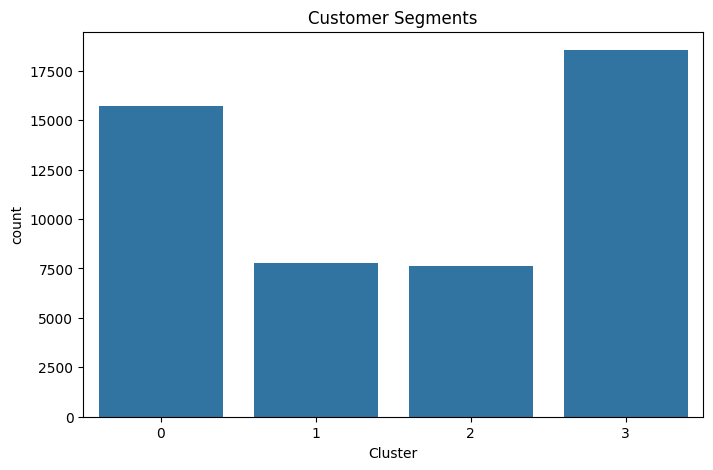

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='Cluster', data=rfm.reset_index())

plt.title("Customer Segments")
plt.show()

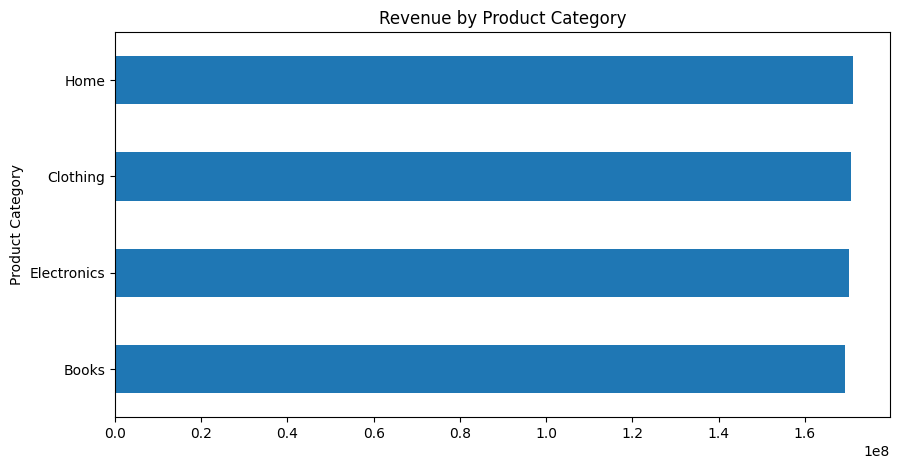

In [ ]:
plt.figure(figsize=(10,5))

df.groupby('Product Category')['Total Purchase Amount'].sum().sort_values().plot(kind='barh')

plt.title("Revenue by Product Category")

plt.show()

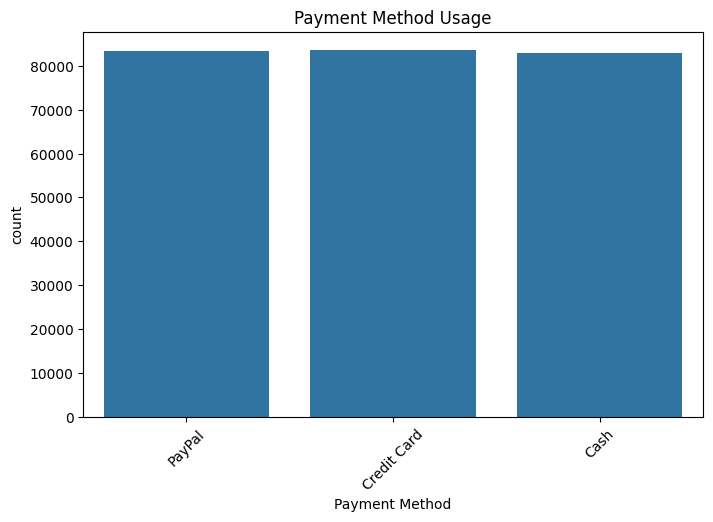

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='Payment Method', data=df)

plt.title("Payment Method Usage")

plt.xticks(rotation=45)

plt.show()

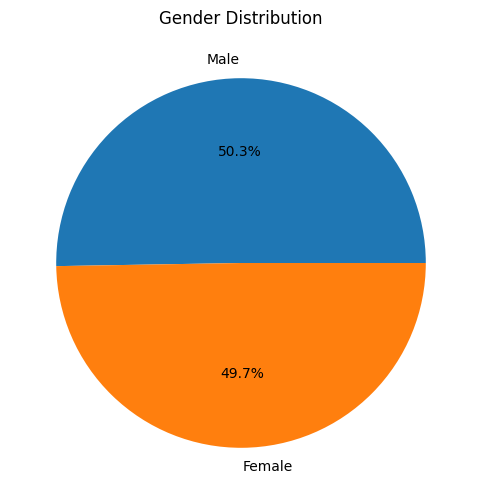

In [ ]:
plt.figure(figsize=(6,6))

df['Gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")

plt.title("Gender Distribution")

plt.show()

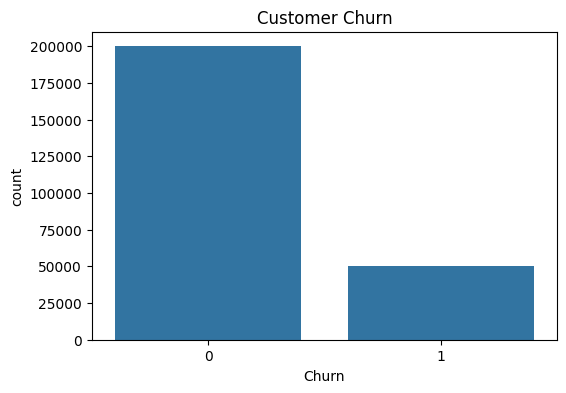

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df)

plt.title("Customer Churn")

plt.show()

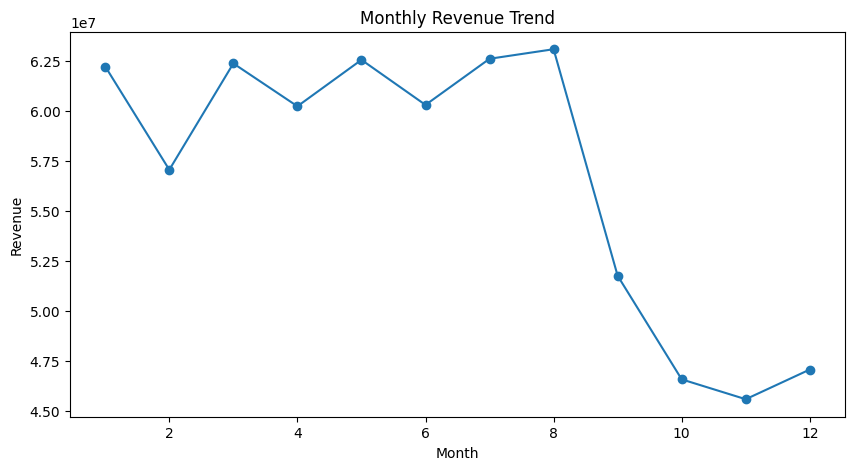

In [ ]:
df['Month'] = df['Purchase Date'].dt.month

monthly_sales = df.groupby('Month')['Total Purchase Amount'].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot(marker='o')

plt.title("Monthly Revenue Trend")

plt.ylabel("Revenue")

plt.show()

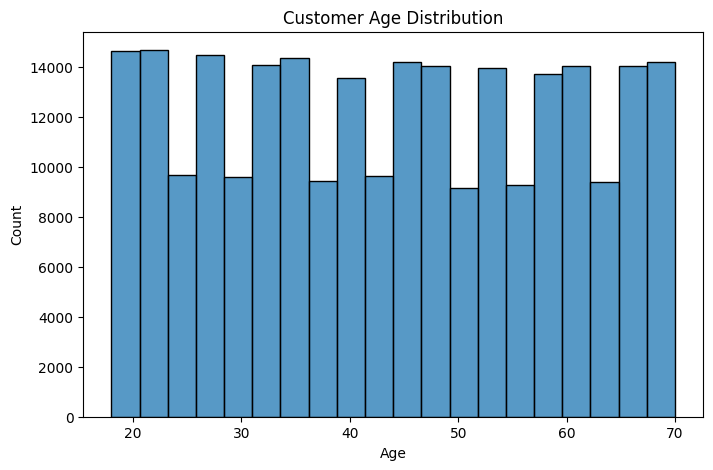

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20)

plt.title("Customer Age Distribution")

plt.show()